In [4]:
# get geometry3k TEST split
!wget https://lupantech.github.io/inter-gps/geometry3k/test.zip
!unzip test.zip

--2026-02-23 07:43:38--  https://lupantech.github.io/inter-gps/geometry3k/test.zip
Resolving lupantech.github.io (lupantech.github.io)... 185.199.111.153, 185.199.109.153, 185.199.108.153, ...
Connecting to lupantech.github.io (lupantech.github.io)|185.199.111.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25524601 (24M) [application/x-zip-compressed]
Saving to: ‘test.zip’

test.zip            100%[===================>]  24.34M  --.-KB/s    in 0.09s   

2026-02-23 07:43:39 (261 MB/s) - ‘test.zip’ saved [25524601/25524601]

Archive:  test.zip
   creating: test/
   creating: test/2925/
  inflating: test/2925/logic_form.json  
  inflating: test/2925/img_diagram_point.png  
  inflating: test/2925/data.json     
  inflating: test/2925/img_diagram.png  
   creating: test/2513/
  inflating: test/2513/logic_form.json  
  inflating: test/2513/img_diagram_point.png  
  inflating: test/2513/data.json     
  inflating: test/2513/img_diagram.png  
   creating: test/24

In [1]:
import json
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def clean_prediction(prediction):
    if not isinstance(prediction, str):
        return None
    match = re.match(r"^\s*([A-D])", prediction)
    if match:
        return match.group(1)
    return None

def load_predictions(filename):
    with open(filename, 'r') as f:
        return json.load(f)

def load_ground_truth(test_dir):
    ground_truth = {}
    for subdir in os.listdir(test_dir):
        data_path = os.path.join(test_dir, subdir, 'data.json')
        if os.path.exists(data_path):
            with open(data_path, 'r') as f:
                data = json.load(f)
                ground_truth[subdir] = {
                    'answer': data.get('answer'),
                    'problem_type_graph': data.get('problem_type_graph', []),
                    'problem_type_goal': data.get('problem_type_goal', [])
                }
    return ground_truth

def analyze_accuracies(predictions, ground_truth):
    results = []
    for pred in predictions:
        problem_id = pred['problem_id']
        if problem_id in ground_truth:
            gt = ground_truth[problem_id]
            cleaned_pred = clean_prediction(pred['prediction'])
            is_correct = cleaned_pred == gt['answer']
            results.append({
                'problem_id': problem_id,
                'prediction': cleaned_pred,
                'ground_truth': gt['answer'],
                'is_correct': is_correct,
                'problem_type_graph': gt['problem_type_graph'],
                'problem_type_goal': gt['problem_type_goal']
            })
    return results

In [6]:
direct_pred_path = 'predictions_direct.json'
direct_pred_with_logic_path = 'predictions_direct_with_logic.json'

dataset_path = 'test/'

In [7]:
direct_preds = load_predictions(direct_pred_path)
direct_with_logic_preds = load_predictions(direct_pred_with_logic_path)
ground_truth = load_ground_truth(dataset_path)

In [8]:
direct_results = analyze_accuracies(direct_preds, ground_truth)
direct_with_logic_results = analyze_accuracies(direct_with_logic_preds, ground_truth)

direct_df = pd.DataFrame(direct_results)
direct_with_logic_df = pd.DataFrame(direct_with_logic_results)

direct_accuracy = direct_df['is_correct'].mean()
direct_with_logic_accuracy = direct_with_logic_df['is_correct'].mean()

print(f"Direct Predictions Accuracy: {direct_accuracy:.2%}")
print(f"Direct with Logic Predictions Accuracy: {direct_with_logic_accuracy:.2%}")

Direct Predictions Accuracy: 35.11%
Direct with Logic Predictions Accuracy: 37.60%


Saved overall accuracy comparison to accuracy_comparison.png


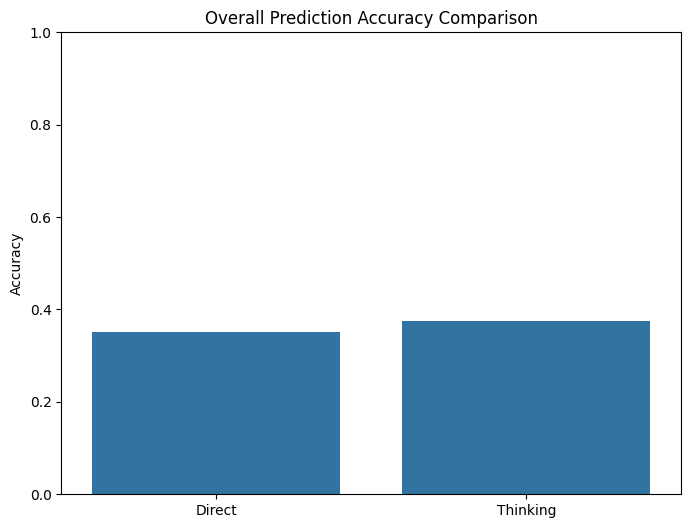

In [10]:
plt.figure(figsize=(8, 6))
sns.barplot(x=['Direct', 'Thinking'], y=[direct_accuracy, direct_with_logic_accuracy])
plt.title('Overall Prediction Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.savefig('accuracy_comparison.png')
print("Saved overall accuracy comparison to accuracy_comparison.png")

In [12]:
direct_df_graph = direct_df.explode('problem_type_graph')
direct_with_logic_df_graph = direct_with_logic_df.explode('problem_type_graph')
direct_df_goal = direct_df.explode('problem_type_goal')
direct_with_logic_df_goal = direct_with_logic_df.explode('problem_type_goal')

Saved accuracy by graph type to accuracy_by_graph_type.png


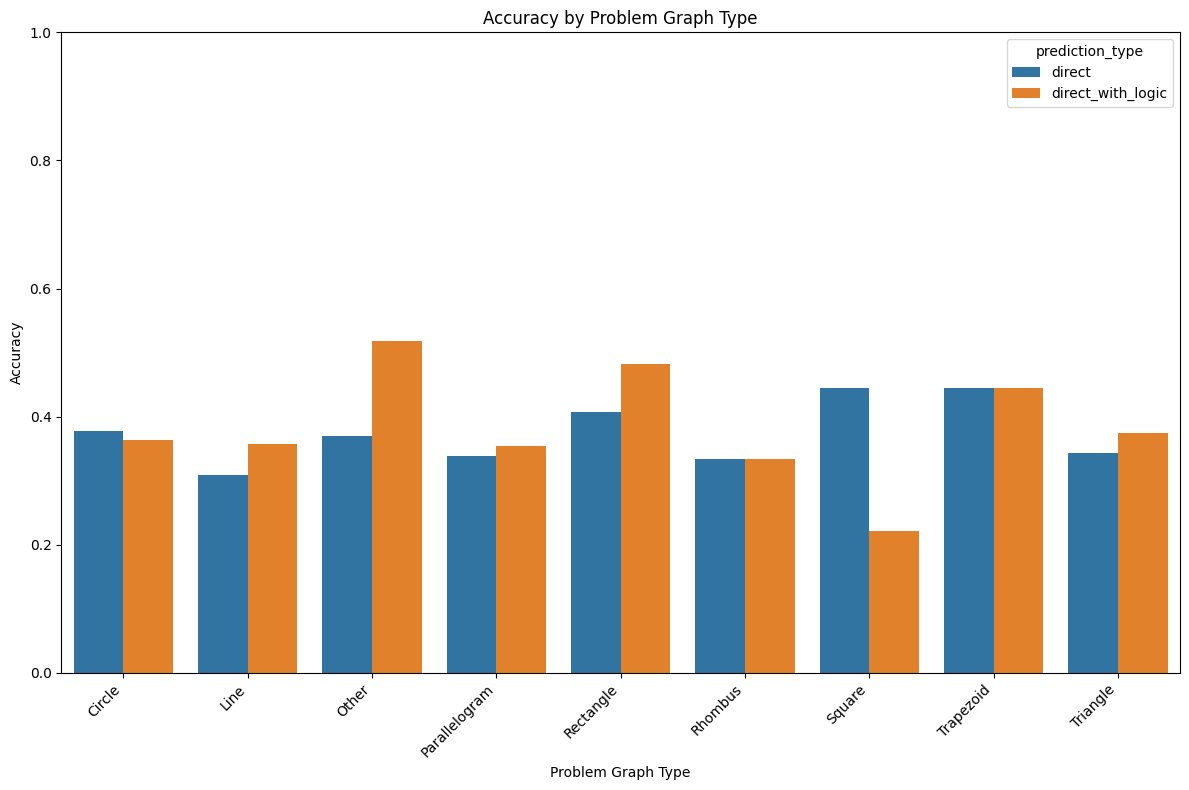

In [13]:
graph_accuracy_direct = direct_df_graph.groupby('problem_type_graph')['is_correct'].mean().reset_index()
graph_accuracy_direct_with_logic = direct_with_logic_df_graph.groupby('problem_type_graph')['is_correct'].mean().reset_index()

graph_accuracy = pd.merge(graph_accuracy_direct, graph_accuracy_direct_with_logic, on='problem_type_graph', suffixes=('_direct', '_direct_with_logic'))
graph_accuracy = pd.melt(graph_accuracy, id_vars='problem_type_graph', value_vars=['is_correct_direct', 'is_correct_direct_with_logic'], var_name='prediction_type', value_name='accuracy')
graph_accuracy['prediction_type'] = graph_accuracy['prediction_type'].str.replace('is_correct_', '')

plt.figure(figsize=(12, 8))
sns.barplot(data=graph_accuracy, x='problem_type_graph', y='accuracy', hue='prediction_type')
plt.title('Accuracy by Problem Graph Type')
plt.ylabel('Accuracy')
plt.xlabel('Problem Graph Type')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('accuracy_by_graph_type.png')
print("Saved accuracy by graph type to accuracy_by_graph_type.png")

Saved accuracy by goal type to accuracy_by_goal_type.png


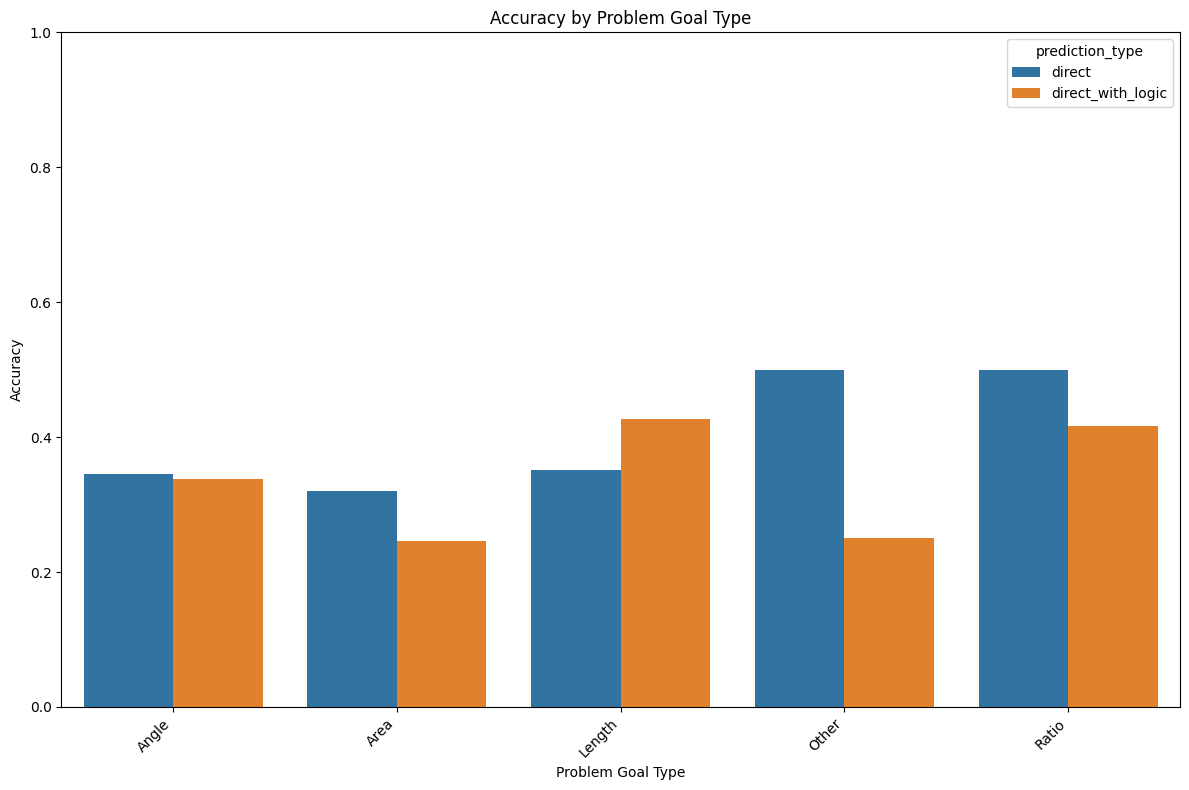

In [14]:
goal_accuracy_direct = direct_df_goal.groupby('problem_type_goal')['is_correct'].mean().reset_index()
graph_accuracy_direct_with_logic = direct_with_logic_df_goal.groupby('problem_type_goal')['is_correct'].mean().reset_index()

goal_accuracy = pd.merge(goal_accuracy_direct, graph_accuracy_direct_with_logic, on='problem_type_goal', suffixes=('_direct', '_direct_with_logic'))
goal_accuracy = pd.melt(goal_accuracy, id_vars='problem_type_goal', value_vars=['is_correct_direct', 'is_correct_direct_with_logic'], var_name='prediction_type', value_name='accuracy')
goal_accuracy['prediction_type'] = goal_accuracy['prediction_type'].str.replace('is_correct_', '')


plt.figure(figsize=(12, 8))
sns.barplot(data=goal_accuracy, x='problem_type_goal', y='accuracy', hue='prediction_type')
plt.title('Accuracy by Problem Goal Type')
plt.ylabel('Accuracy')
plt.xlabel('Problem Goal Type')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('accuracy_by_goal_type.png')
print("Saved accuracy by goal type to accuracy_by_goal_type.png")